<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [5]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




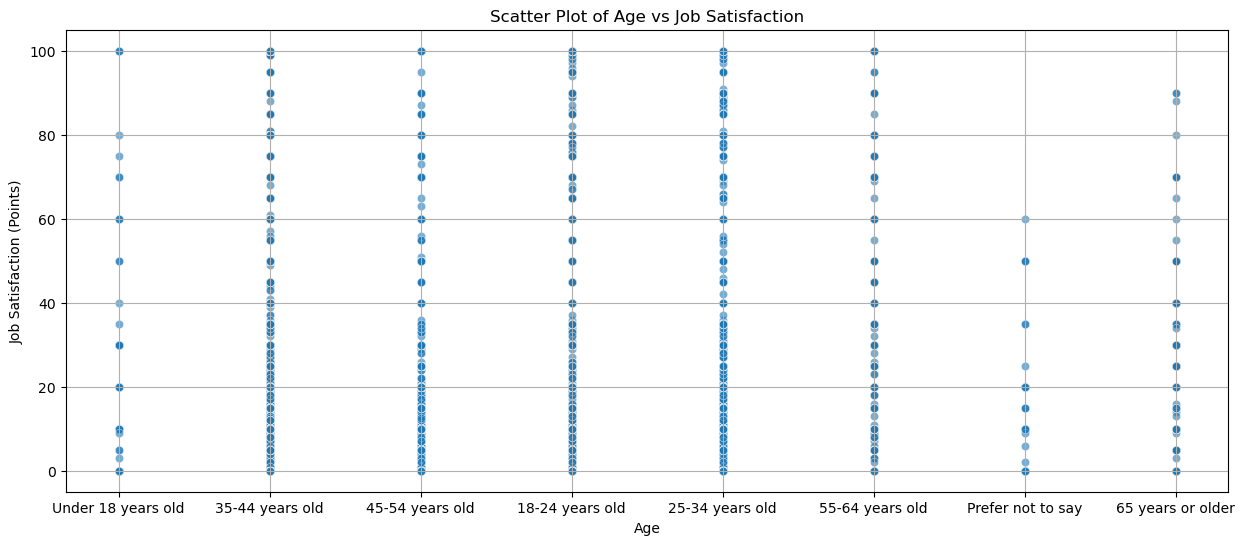

In [7]:
## Write your code here

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(15,6))
sns.scatterplot(data=df, x='Age', y='JobSatPoints_6', alpha=0.6)
plt.title('Scatter Plot of Age vs Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


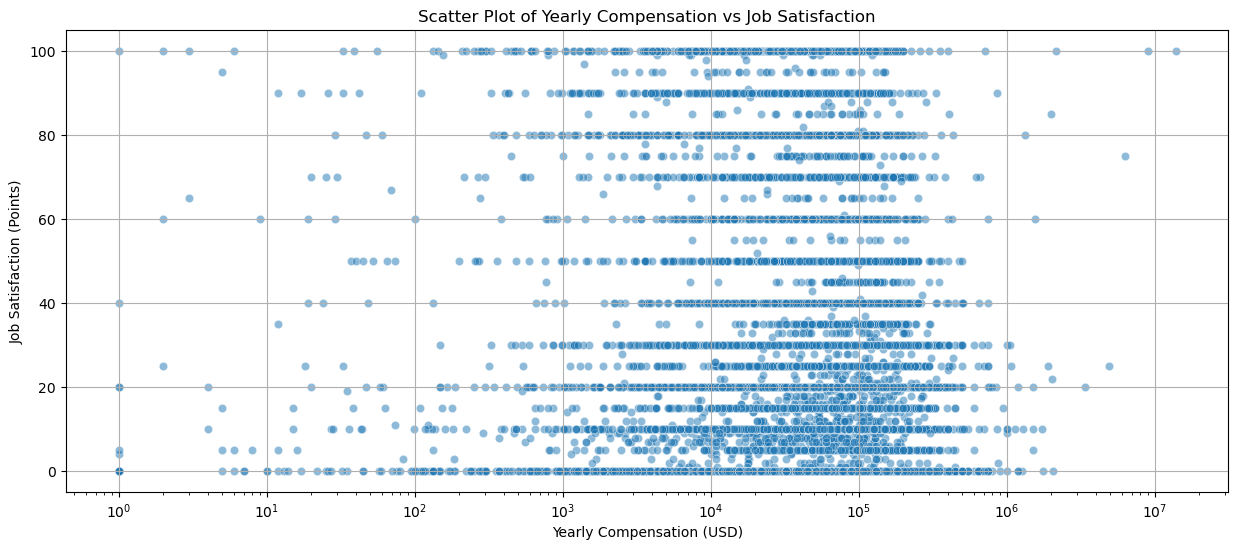

In [9]:
## Write your code here

# Scatter Plot: Compensation vs Job Satisfaction
plt.figure(figsize=(15,6))
sns.scatterplot(data=df, x='ConvertedCompYearly', y='JobSatPoints_6', alpha=0.5)
plt.title('Scatter Plot of Yearly Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction (Points)')
plt.xscale('log')  # Optional: log scale to handle large salary variations
plt.grid(True)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


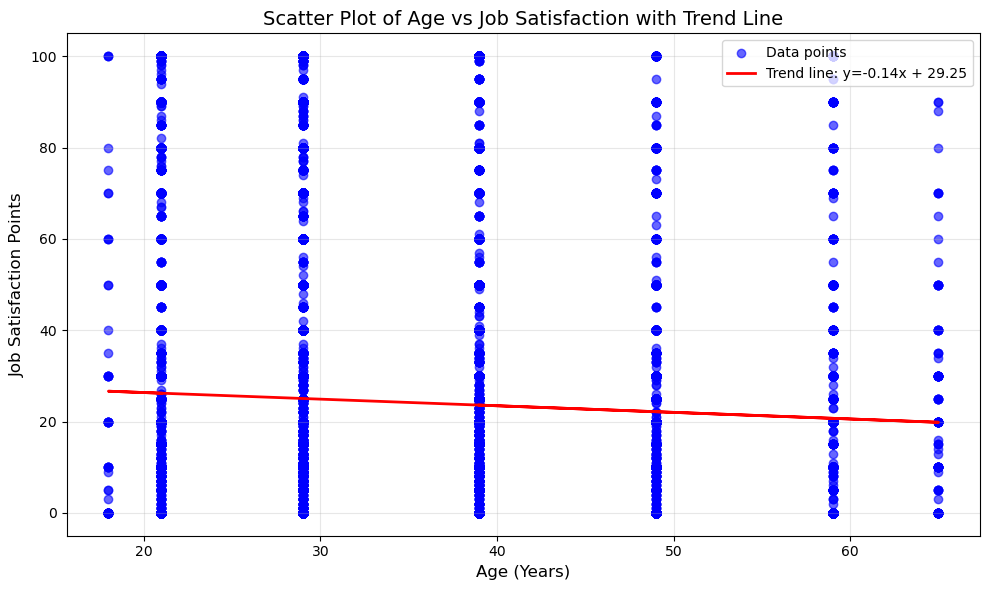

In [12]:
## Write your code here

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Load Age and Job Satisfaction ---


file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path, usecols=['Age', 'JobSatPoints_6'])



# --- 2. Clean and convert Age ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))  # average if a range

df['Age_clean'] = df['Age'].map(parse_age)

# --- 3. Clean Job Satisfaction ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing values
df_plot = df.dropna(subset=['Age_clean', 'JobSat_clean'])

# --- 4. Scatter Plot ---
plt.figure(figsize=(10,6))
plt.scatter(df_plot['Age_clean'], df_plot['JobSat_clean'], alpha=0.6, color='blue', label='Data points')

# --- 5. Add Regression Line ---
# Fit linear regression
x = df_plot['Age_clean']
y = df_plot['JobSat_clean']
coeffs = np.polyfit(x, y, deg=1)  # linear fit
y_fit = np.polyval(coeffs, x)
plt.plot(x, y_fit, color='red', linewidth=2, label=f'Trend line: y={coeffs[0]:.2f}x + {coeffs[1]:.2f}')

plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Job Satisfaction Points', fontsize=12)
plt.title('Scatter Plot of Age vs Job Satisfaction with Trend Line', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


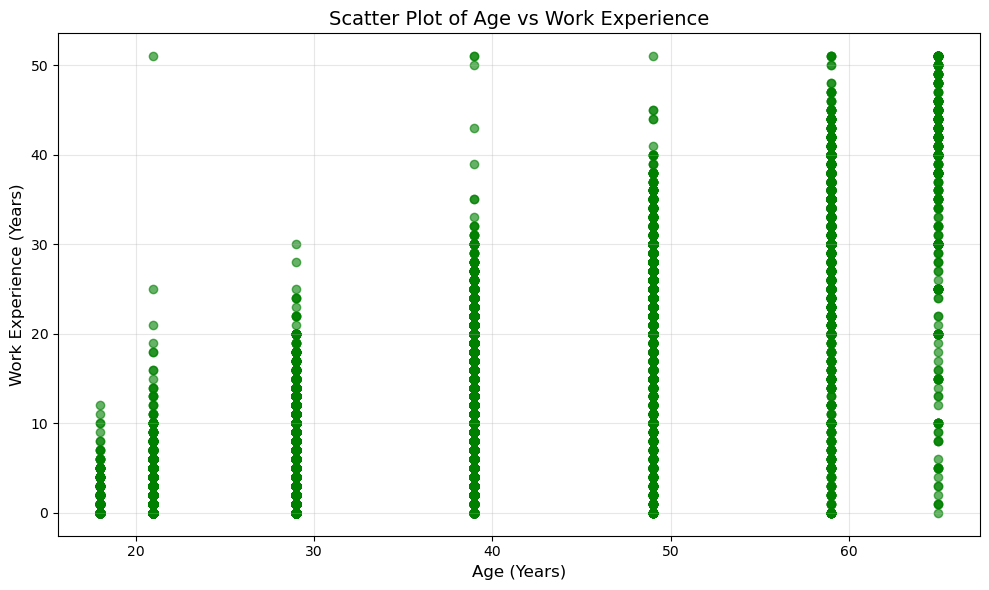

In [24]:
## Write your code here

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Load Age and YearsCodePro ---
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path, usecols=['Age', 'YearsCodePro'])


# --- 2. Clean and convert Age ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))

df['Age_clean'] = df['Age'].map(parse_age)

# --- 3. Clean and convert YearsCodePro ---
def parse_years(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'less than 1 year'}:
        return 0
    if 'more than' in s:
        nums = re.findall(r'\d+', s)
        return int(nums[0]) + 1 if nums else np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))  # average if a range

df['YearsCodePro_clean'] = df['YearsCodePro'].map(parse_years)

# --- 4. Drop missing values ---
df_plot = df.dropna(subset=['Age_clean', 'YearsCodePro_clean'])

# --- 5. Scatter Plot ---
plt.figure(figsize=(10,6))
plt.scatter(df_plot['Age_clean'], df_plot['YearsCodePro_clean'], alpha=0.6, color='green')

plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Work Experience (Years)', fontsize=12)
plt.title('Scatter Plot of Age vs Work Experience', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


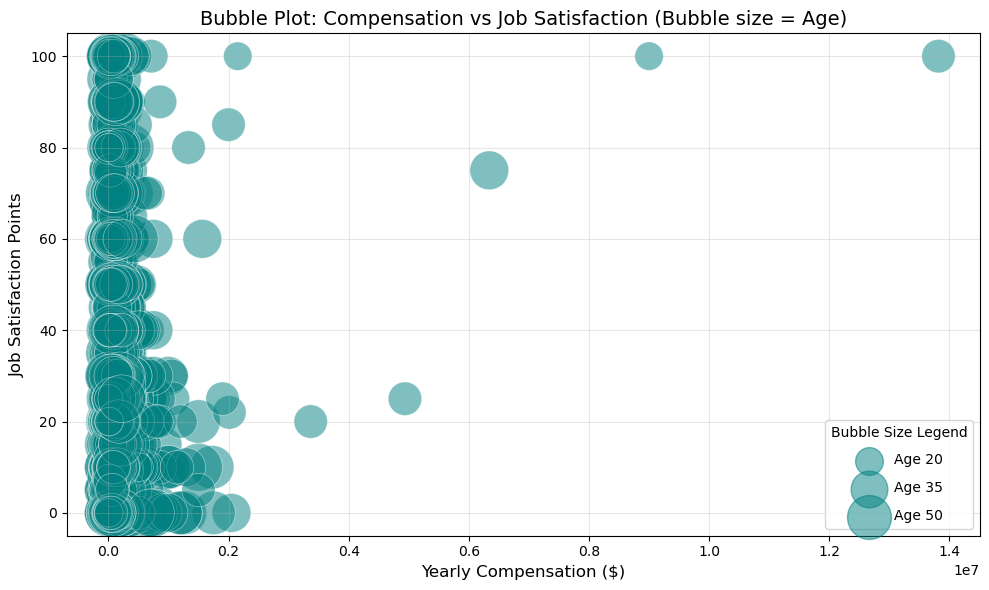

In [11]:
## Write your code here


import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Load data ---

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path, usecols=['Age', 'ConvertedCompYearly','JobSatPoints_6'])


# --- 2. Clean Age ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))

df['Age_clean'] = df['Age'].map(parse_age)

# --- 3. Clean ConvertedCompYearly ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompClean'] = df['ConvertedCompYearly'].map(parse_compval)

# --- 4. Clean Job Satisfaction ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# --- 5. Filter valid rows ---
df_plot = df.dropna(subset=['Age_clean', 'CompClean', 'JobSat_clean'])
df_plot = df_plot[df_plot['CompClean'] > 0]

# --- 6. Create Bubble Plot ---
plt.figure(figsize=(10,6))

# Bubble size scaling
size_scale = 20
plt.scatter(
    df_plot['CompClean'],
    df_plot['JobSat_clean'],
    s=df_plot['Age_clean']*size_scale,  # bubble size proportional to age
    alpha=0.5,
    color='teal',
    edgecolors='w',
    linewidth=0.5
)

plt.xlabel('Yearly Compensation ($)', fontsize=12)
plt.ylabel('Job Satisfaction Points', fontsize=12)
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble size = Age)', fontsize=14)
plt.grid(alpha=0.3)

# Optional: create legend for bubble sizes
for age in [20, 35, 50]:
    plt.scatter([], [], s=age*size_scale, color='teal', alpha=0.5,
                label=f'Age {age}')
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title='Bubble Size Legend')

plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


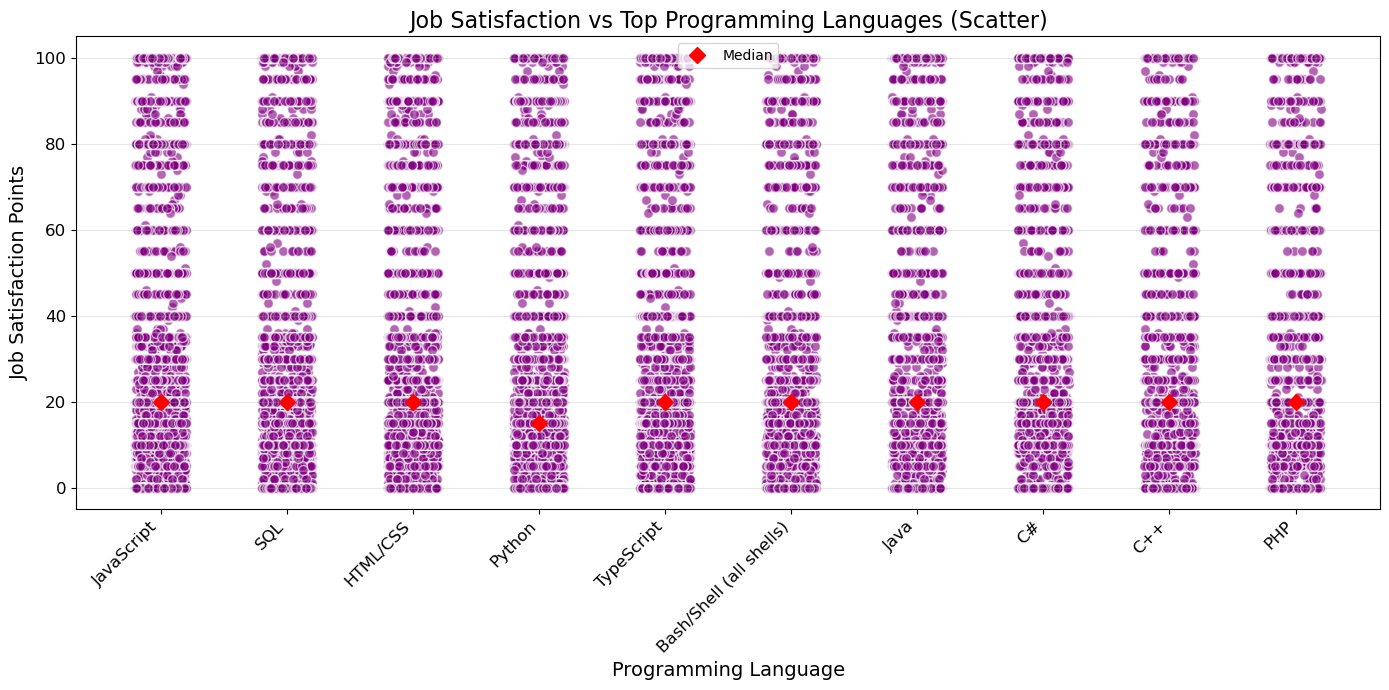

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load data ---
df = pd.read_csv(file_path, usecols=['LanguageHaveWorkedWith', 'JobSatPoints_6'])

# --- 2. Convert Job Satisfaction to numeric and drop missing ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSat_clean'])

# --- 3. Explode multiple languages ---
df['Language_list'] = df['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df.explode('Language_list')
df_exploded['Language_list'] = df_exploded['Language_list'].str.strip()

# --- 4. Select top 10 languages ---
top_languages = df_exploded['Language_list'].value_counts().head(10).index.tolist()
df_plot = df_exploded[df_exploded['Language_list'].isin(top_languages)].copy()  # ensure copy to avoid warnings

# --- 5. Scatter plot with jitter ---
plt.figure(figsize=(14,7))
# Jitter X-axis
x_positions = [top_languages.index(lang) + np.random.uniform(-0.2, 0.2) for lang in df_plot['Language_list']]

plt.scatter(
    x_positions,
    df_plot['JobSat_clean'],
    alpha=0.6,
    color='purple',
    s=50,
    edgecolors='w'
)

# Median markers
for i, lang in enumerate(top_languages):
    median_val = df_plot[df_plot['Language_list'] == lang]['JobSat_clean'].median()
    plt.plot(i, median_val, 'rD', markersize=8, label='Median' if i==0 else "")

plt.xticks(range(len(top_languages)), top_languages, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Programming Language', fontsize=14)
plt.ylabel('Job Satisfaction Points', fontsize=14)
plt.title('Job Satisfaction vs Top Programming Languages (Scatter)', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [21]:
df

,JobSatPoints_6,ConvertedCompYearly,CompClean,JobSat_clean
0,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,0.0
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
65432,NaN,NaN,NaN,NaN
65433,NaN,NaN,NaN,NaN
65434,NaN,NaN,NaN,NaN
65435,0.0,NaN,NaN,0.0


C:\Users\praka\AppData\Local\Temp\ipykernel_21564\2231901537.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


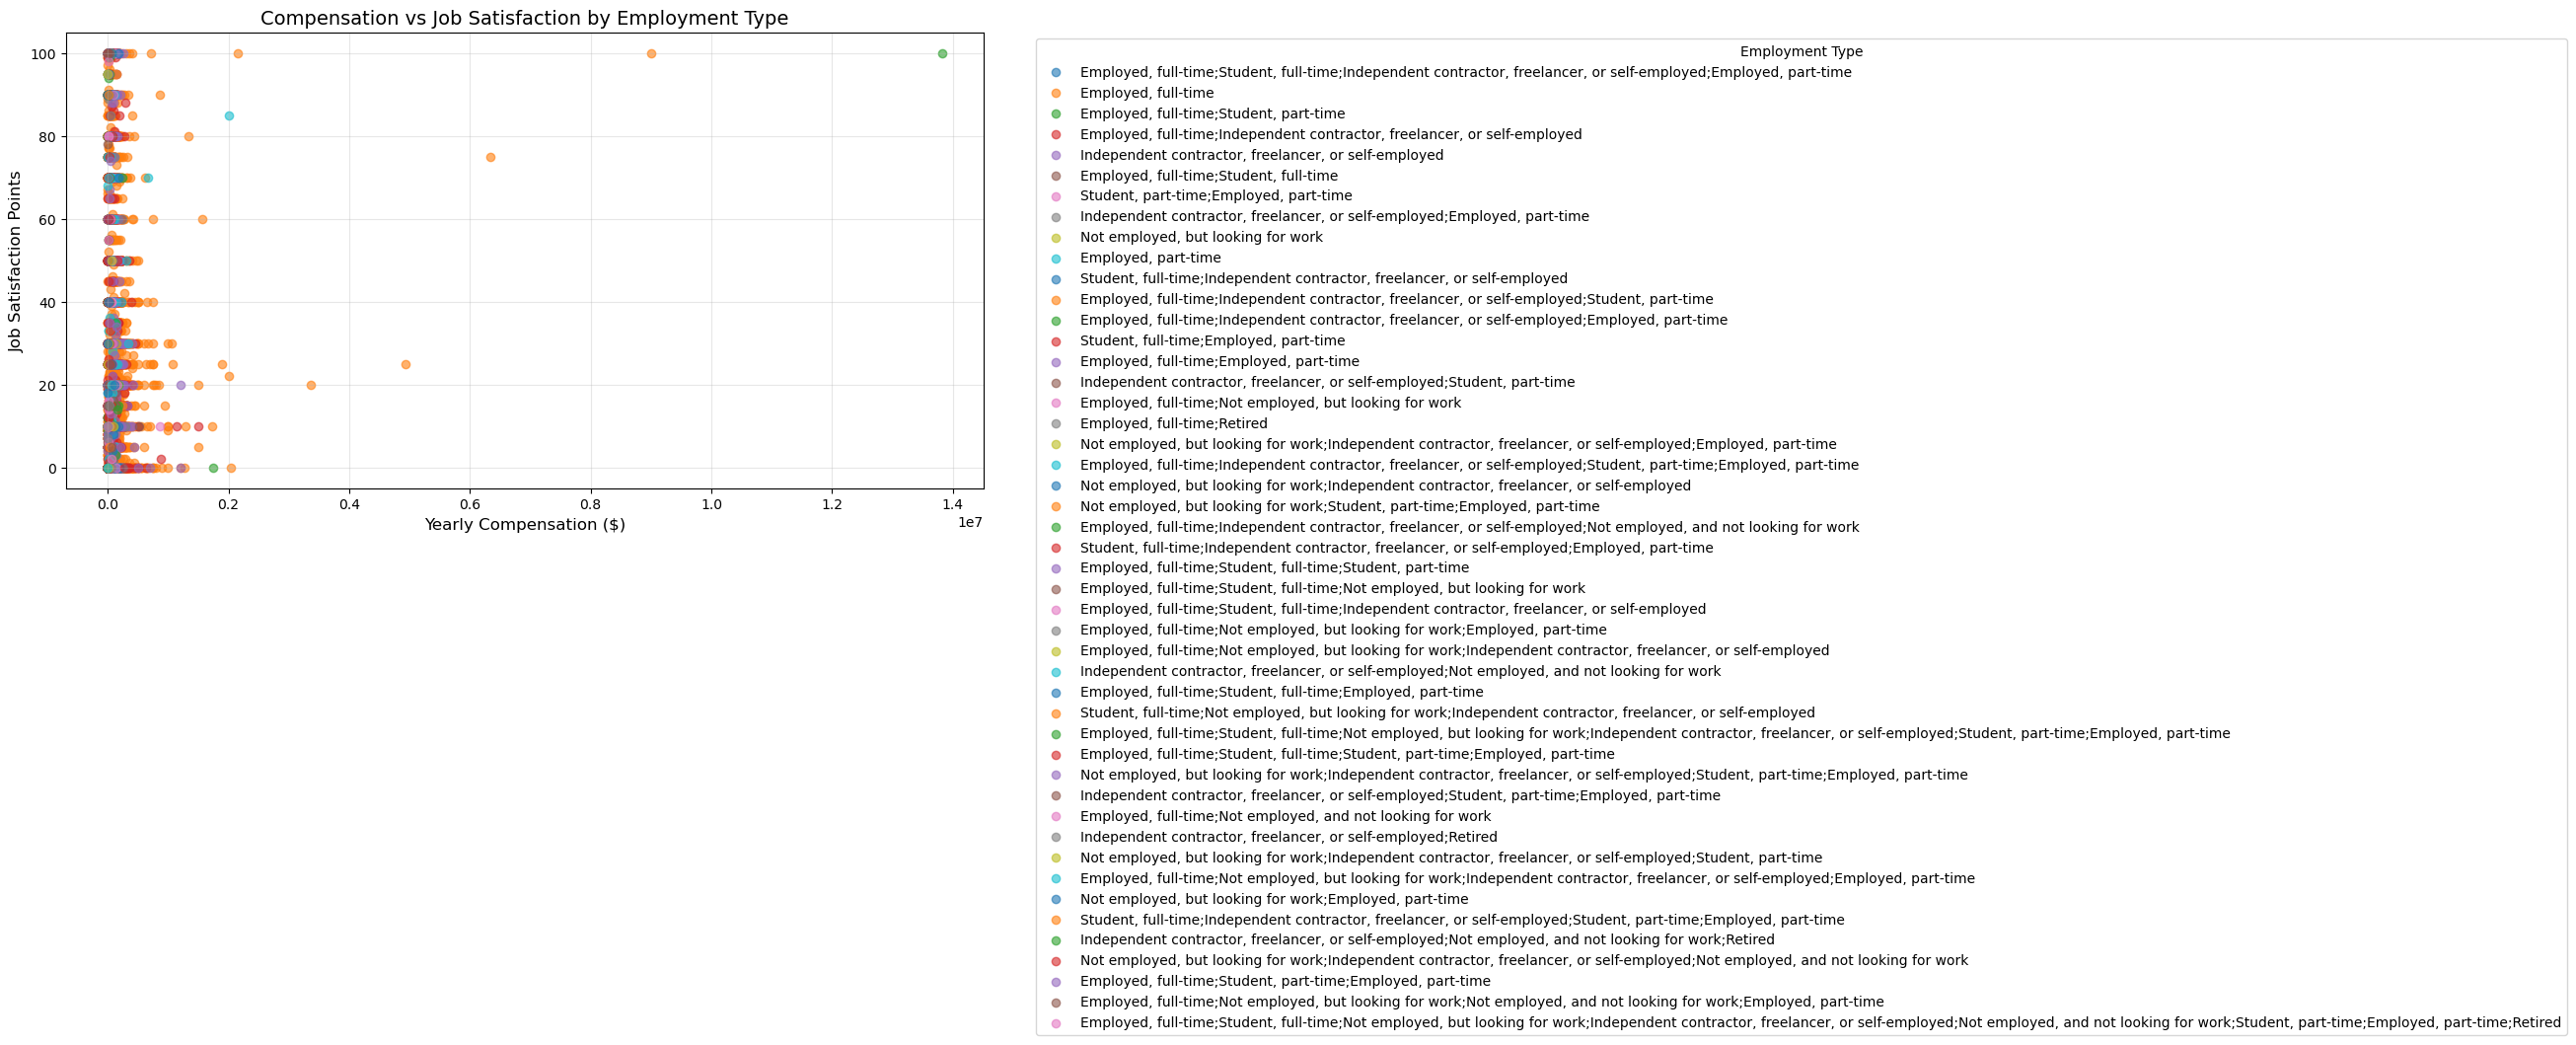

In [23]:
## Write your code here

df = pd.read_csv(file_path, usecols=['ConvertedCompYearly', 'JobSatPoints_6','Employment'])

# --- 2. Clean ConvertedCompYearly ---
def parse_compval(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return None
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return None
    nums = [float(n) for n in nums]
    return float(sum(nums)/len(nums))

df['CompClean'] = df['ConvertedCompYearly'].map(parse_compval)

# --- 3. Clean Job Satisfaction ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# --- 4. Filter valid rows ---
df_plot = df.dropna(subset=['Employment', 'CompClean', 'JobSat_clean'])
df_plot = df_plot[df_plot['CompClean'] > 0]

# --- 5. Identify unique employment types ---
employment_types = df_plot['Employment'].unique()
colors = plt.cm.tab10.colors  # color palette

# --- 6. Scatter Plot ---
plt.figure(figsize=(12,6))
for i, emp_type in enumerate(employment_types):
    subset = df_plot[df_plot['Employment'] == emp_type]
    plt.scatter(
        subset['CompClean'],
        subset['JobSat_clean'],
        alpha=0.6,
        color=colors[i % len(colors)],
        label=emp_type
    )

plt.xlabel('Yearly Compensation ($)', fontsize=12)
plt.ylabel('Job Satisfaction Points', fontsize=12)
plt.title('Compensation vs Job Satisfaction by Employment Type', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


C:\Users\praka\AppData\Local\Temp\ipykernel_21564\528519265.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['Age_Group'] = pd.cut(df_plot['Age_clean'], bins=age_bins, labels=age_labels, right=True)


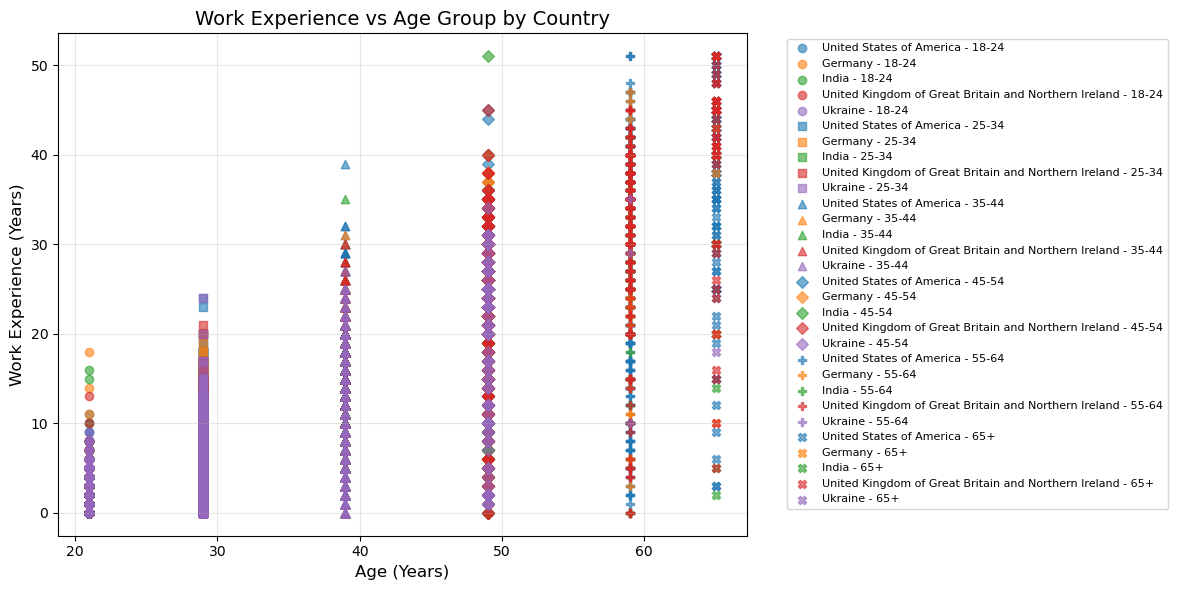

In [25]:
## Write your code here



df = pd.read_csv(file_path, usecols=['Age', 'YearsCodePro','Country'])


# --- 2. Clean Age ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))

df['Age_clean'] = df['Age'].map(parse_age)

# --- 3. Clean Work Experience ---
def parse_years(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'less than 1 year'}:
        return 0
    if 'more than' in s:
        nums = re.findall(r'\d+', s)
        return int(nums[0]) + 1 if nums else np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))

df['YearsCodePro_clean'] = df['YearsCodePro'].map(parse_years)

# --- 4. Drop missing values ---
df_plot = df.dropna(subset=['Age_clean', 'YearsCodePro_clean', 'Country'])

# --- 5. Create Age Groups ---
age_bins = [18, 24, 34, 44, 54, 64, 100]
age_labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df_plot['Age_Group'] = pd.cut(df_plot['Age_clean'], bins=age_bins, labels=age_labels, right=True)

# --- 6. Identify top 5 countries by count for clarity ---
top_countries = df_plot['Country'].value_counts().head(5).index.tolist()
df_plot = df_plot[df_plot['Country'].isin(top_countries)]

# --- 7. Scatter Plot ---
plt.figure(figsize=(12,6))
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'D', 'P', 'X', '*']  # for age groups

for i, age_group in enumerate(age_labels):
    subset = df_plot[df_plot['Age_Group'] == age_group]
    for j, country in enumerate(top_countries):
        data = subset[subset['Country'] == country]
        plt.scatter(
            data['Age_clean'],
            data['YearsCodePro_clean'],
            color=colors[j % len(colors)],
            marker=markers[i % len(markers)],
            alpha=0.6,
            label=f'{country} - {age_group}'  # combination in legend
        )

plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Work Experience (Years)', fontsize=12)
plt.title('Work Experience vs Age Group by Country', fontsize=14)
plt.grid(alpha=0.3)

# Reduce legend clutter
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
